## Análisis estadístico para evaluación de muestras single-cell

Este análisis se centra en la evaluación de los conteos (umi_count) para la combinación de células y pacientes. En general, en este análisis se tienen los siguientes puntos en consideración, información previa y supuestos:

1. Para la combinación de célula y paciente el estado ideal de los conteos se asocia a dos transcritos altamente expresados.
2. Existen situaciones en las que adicionales a los dos transcritos con alto valor de conteo, aparecen nuevos transcritos que mezclan o poseen información mixta entre los transcritos de alto valor.
3. El fenómeno anterior aparece con menor frecuencia para 4 o más transcritos.
4. Existe una regla inicial que indica que en una combinación célula/paciente presenta dos transcritos en alta proporción y el resto de los transcritos en baja proporción.

A partir de los supuestos y la información de la detección de los problemas planteados se define el objetivo:

- Identificar células/pacientes que no se apeguen a la regla general vía la utilización de estrategias estadísticas.

Para resolver este problema, se plantea una estrategía mixta, que implica el análisis de criterios estadísticos en función de las proporciones, aplicaciones de mixture models para identificar divisiones en distribuciones bimodales y el empleo de estrategias de distribución binomial para estimar la probabilidad de eventos exitosos en función de las probabilidades.

A continuación, se desarrolla la implementación y se describen de manera general las etapas desarroladas para este planteamiento.

### Load libraries

In [178]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import vapeplot
import numpy as np
from scipy.stats import binom, norm
from scipy.signal import find_peaks, argrelextrema

vapeplot.set_palette('macplus')
plt.rc('axes', grid=False, facecolor="white")
plt.rcParams.update({'font.size': 18})

### Function's implementation

In [179]:
''' 
    Name function: 
        get_prob_by_cell
    Params:
        - df_data: dataset with umi counts
        - cell: cell to process
        - subject: subject to process
    Description:
        Filter the dataset using the cell and subject input, obtain the number of success (binarization process == 1).
        and apply the binomial probability function to estimate the probability of success.
    Return:
        - probability: probability estimated using the binomial distribution
'''
def get_prob_by_cell(df_data=None, cell=None, subject=None):

    df_filter = df_data.loc[(df_data['cell'] == cell) & (df_data['subject'] == subject)]
    
    df_filter_success = df_filter[df_filter['binarized_proportion'] == 1]
    n= len(df_filter)
    p= len(df_filter_success)/n

    probability = binom.pmf(len(df_filter_success), n, p)
    return probability

In [180]:
''' 
    Name function: 
        generate_proportion_data
    Params:
        - df_data: dataset to process
    Description:
        Function to estimate the proportion value in function of the cell and subject.
    Return:
        - df_grouped: dataset with the grouped values (cell, subject)
        - df_merge: input dataset merged with the proportion estimated
'''
def generate_proportion_data(df_data):
    df_data_filter = df_data[['cell', 'subject', 'umi_count']]
    df_group = df_data_filter.groupby(by=["cell", "subject"]).sum()

    matrix_data = []

    for index in df_group.index:
        cell = index[0]
        subject = index[1]
        umi_count = df_group['umi_count'][index]
        row = [cell, subject, umi_count]
        matrix_data.append(row)

    df_grouped = pd.DataFrame(matrix_data, columns=['cell', 'subject', 'umi_count_per_combination'])
    df_merge = df_data.merge(df_grouped, on=["cell", "subject"])
    df_merge['proportion'] = df_merge['umi_count']/df_merge['umi_count_per_combination']

    return df_grouped, df_merge

In [181]:
''' 
    Name function: 
        create_division_point_bimodal
    Params:
        - df_data: dataset to process with the estimated proportion
        - filter_point: filter value used to fit the criteion value
    Description:
        Function to estimate the division point in a bimodal distribution
    Return:
        - division_point: point employed to split a bimodal distribution
'''
def create_division_point_bimodal(df_data=None, filter_point=0.7):
    hist, bin_edges = np.histogram(df_data['proportion'].values, bins=30, density=True)

    peaks, _ = find_peaks(hist)
    # Find local minima (valleys) between the peaks
    valleys = argrelextrema(hist, np.less)
    division_point = filter_point * (bin_edges[valleys[0][0]] + bin_edges[valleys[0][1]])
    return division_point

In [182]:
''' 
    Name function: 
        process_data_by_bi_modal
    Params:
        - df_grouped: grouped dataset by cell/subject
        - df_merge: processed dataset with all estimated values and descriptions
    Description:
        Function to summarize the processed dataset and to estimate positive and negative nucl_combination based on 
        the distribution employed and the filter criterion applied.
    Return:
        - df_check: summary dataset for the input elements
'''
def process_data_by_bi_modal(df_grouped=None, df_merge=None):
    matrix_check = []

    for index in df_grouped.index:
        cell = df_grouped["cell"][index]
        subject = df_grouped["subject"][index]

        filter_df = df_merge[(df_merge["cell"] == cell) & (df_merge["subject"] == subject)]

        positive = len(filter_df[filter_df["binarized_proportion"] == 1])
        negative = len(filter_df[filter_df["binarized_proportion"] == 0])

        row = [cell, subject, positive, negative]
        matrix_check.append(row)

    df_check = pd.DataFrame(matrix_check, columns=["cell", "subject", "positive", "negative"])
    return df_check

In [183]:
''' 
    Name function: 
        check_cells_in_data
    Params:
        - filter_data: dataset to check the status based on the input data
        - cell: cell to evaluate
        - subject: subject to evaluate
    Description:
        Function to evaluate if a cell is in the filter_data dataset or not
    Return:
        - is_error: cell's status
'''
def check_cells_in_data(filter_data, cell, subject):
    is_error = False

    for index in filter_data.index:
        cell_value = filter_data['cell'][index]
        subject_value = filter_data['subject'][index]

        if cell == cell_value and subject == subject_value:
            is_error = True
            break
    return is_error

### Etapa 1: Lectura y creación distribución

- Se lee el dataset empleando pandas y la función read_excel, luego se estima la proporción de umi by cell/subject y se analiza la distribución de las proporciones. 

- Se identifica una distribución bimodal y se estima el punto de corte para generar la división entre los dos peaks obtenidos. En este caso, el punto de corte es una proporción de 0.1377

- La interpretación de esta división es: 
    - **Mayor al punto criterio**: indica que la proporción es alta. Esto implica que puede ser transcritos normales dentro de la célula. Sin embargo, deben ser analizados en función de los elementos restantes de la célula.
    - **Menor al punto criterio**: indica que la proporción es baja. Esto implica que pueden ser transcritos con mezcla de información, errores en la secuenciación, etc. Sin embargo, para descartar la célula, deben ser analizados el resto de los componentes.

Intuitivamente, aparecen dos reglas que se emplean para desarrollar los filtros correspondientes de la primera etapa:

- Cuando se tiene un valor positivo de 2 (2 transcritos con alta proporción en función de la distribución poblacional) y 0 negativos (0 nucl_combination), implica que es una célula clasificada como *"normal"*, indicando que solo presenta dos transcritos en proporciones altas, no necesariamente similares entre ellas (las distribuciones).
- Cuando se tiene un valor positivo > 2 y un valor negativo de 0, implica que es una célula clasificada como *"Filter by bi-modal"*. Esto se interpreta como:
    - Célula/subject con más de dos transcritos y todos en proporciones altas en función de la distribución, no necesariamente con similar distribución entre ellos. Esto último corresponde claramente a un error ya que se contradice con los supuestos iniciales. 
    - Esto se podría interpretar matemáticamente como una *"demostración por el absurdo"*, ya que en realidad se demuestra la hipótesis contraria.

In [184]:
df_data = pd.read_excel("umi_combinations_v2.xlsx") # read
df_grouped, df_merge = generate_proportion_data(df_data) # process data by proportion

# get division point for separating bi-modal distribution
division_point = create_division_point_bimodal(df_data=df_merge, filter_point=0.7)
division_point

0.13774193548387095

### Ploting proportion distribution

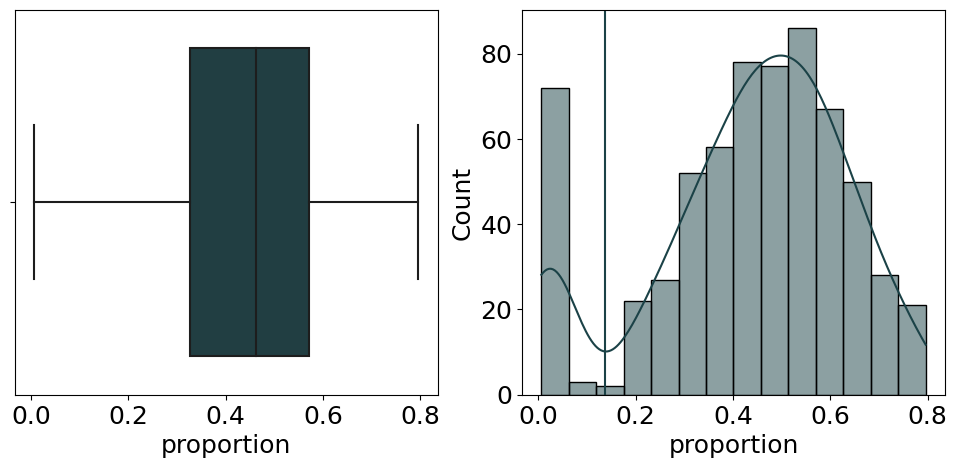

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(ax=axes[0], data=df_merge, x="proportion")
sns.histplot(ax=axes[1], data=df_merge, x="proportion", kde=True)
plt.axvline(division_point, 0,80)

### Process by bimodal distribution

Se aplican los filtros y estrategias de procesamiento previamente explicadas, generando un dataset con la información de células clasificadas como *Filter by bi-modal* y las clasificadas como *normal cell*.

El dataset generado en esta etapa se emplea como input para la etapa 2 del pipeline de evaluación de transcritos en single-cell

In [186]:
df_merge["binarized_proportion"] = (df_merge["proportion"] >= division_point).astype(int) #binarization by criterion
df_check = process_data_by_bi_modal(df_grouped=df_grouped, df_merge=df_merge) # get summary process

# First rule: all cells with more than three positive counts and cero counts are bad cells because are cells with low proportion in similar conditions
filter_error_cells = df_check[(df_check['negative'] == 0) & (df_check['positive'] > 2)]
merge_filter = filter_error_cells.merge(right=df_merge, on=["cell", "subject"])

merge_filter['criterion_filter'] = "Filter by bi-modal"

# Second criterion: All cells with positive == 2 and negative = 0 are OK
remove_positive = df_check[(df_check['negative'] == 0) & (df_check['positive'] == 2)]
merge_filter_positive = remove_positive.merge(right=df_merge, on=["cell", "subject"])

merge_filter_positive['criterion_filter'] = "normal cell"

df_processed_concat = pd.concat([merge_filter, merge_filter_positive], axis=0)
df_processed_concat.reset_index(inplace=True)
df_processed_concat = df_processed_concat.drop(columns=["index"])

### Etapa 2: Evaluación por probabilidad de éxito empleando distribuciones binomiales

La segunda etapa del procesamiento corresponde a emplear la binarización de las proporciones y desarrollar un análisis de experimentos Bernulli. Con estos experimentos, se desarrolla una distribución binomial para la combinación célula/subject y se estima la probabilidad de éxito del evento. Luego, se modela la distribución de probabilidad y se aplica un umbral configurable para hacer los filtros.

#### Filtrando las células/sujetos pendientes por analizar

In [187]:
cell_error = df_processed_concat['cell'].values
subject_error = df_processed_concat['subject'].values

matrix_values_stage_2 = []
for index in df_merge.index:
    cell = df_merge['cell'][index]
    subject = df_merge['subject'][index]

    if check_cells_in_data(df_processed_concat, cell, subject) == False:
        matrix_values_stage_2.append(
            df_merge.iloc[index].values
        )

df_filter_stage_2 = pd.DataFrame(matrix_values_stage_2, columns=df_merge.columns)
df_filter_stage_2

,subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type,alternative_type,match_percentage_po,highest_count,label,total_umi,umi_percentage,subject_type,umi_count_per_combination,proportion,binarized_proportion
0,K6B_S13530-HC,AGTTGGTTCTGATACG,"291:C, 255:T, 261:G, 367:T, 400:G","291:G, 255:C, 261:G, 367:C, 400:C",5,105,3,PO-Neo,unexpected,highest_umi_count,20.000000,1,Highest,159,66.037736,HC,159,0.660377,1
1,K6B_S13530-HC,AGTTGGTTCTGATACG,"291:G, 255:C, 261:A, 367:C, 400:A","291:G, 255:C, 261:G, 367:C, 400:C",5,53,3,PO-Neo,unexpected,all positions alternative,60.000000,1,Opposite,159,33.333333,HC,159,0.333333,1
2,K6B_S13530-HC,AGTTGGTTCTGATACG,"291:C, 255:T, 261:G, 367:C, 400:G","291:G, 255:C, 261:G, 367:C, 400:C",5,1,3,PO-Neo,unexpected,partial alternative 1,40.000000,1,partial alternative 1,159,0.628931,HC,159,0.006289,0
3,K6B_S13530-LC,CGGAGCTAGATCACGG,"122:A, 196:C, 278:T, 306:T, 207:A, 187:T, 192:C","122:G, 196:C, 278:T, 306:C, 207:A, 187:T, 192:C",7,104,4,PO-Neo,unexpected,highest_umi_count,71.428571,1,Highest,136,76.470588,LC,136,0.764706,1
4,K6B_S13530-LC,CGGAGCTAGATCACGG,"122:G, 196:T, 278:A, 306:C, 207:G, 187:C, 192:T","122:G, 196:C, 278:T, 306:C, 207:A, 187:T, 192:C",7,30,4,PO-Neo,unexpected,all positions alternative,28.571429,1,Opposite,136,22.058824,LC,136,0.220588,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,K7B_S10000-LC,GTTCATTAGAAACGCC,"193:A, 375:C, 378:T","193:A, 375:C, 378:C",3,1,4,PO-Neo,unexpected,partial alternative 1,66.666667,1,partial alternative 1,25,4.000000,LC,25,0.040000,0
202,K7B_S10000-LC,GTTCATTAGAAACGCC,"193:A, 375:C, 378:C","193:A, 375:C, 378:C",3,1,4,PO,unexpected,partial alternative 2,100.000000,1,partial alternative 2,25,4.000000,LC,25,0.040000,0
203,K8B_S13553-LC,CATCAGAAGGGTGTGT,"213:G, 200:G, 335:C, 203:A, 229:G","213:G, 200:A, 335:G, 203:A, 229:G",5,11,3,PO-Neo,unexpected,highest_umi_count,60.000000,1,Highest,22,50.000000,LC,22,0.500000,1
204,K8B_S13553-LC,CATCAGAAGGGTGTGT,"213:C, 200:A, 335:G, 203:T, 229:T","213:G, 200:A, 335:G, 203:A, 229:G",5,10,3,PO-Neo,unexpected,all positions alternative,40.000000,1,Opposite,22,45.454545,LC,22,0.454545,1


### Ploteo de la distribución de las proporciones pendientes por analizar.

<AxesSubplot: xlabel='proportion', ylabel='Count'>

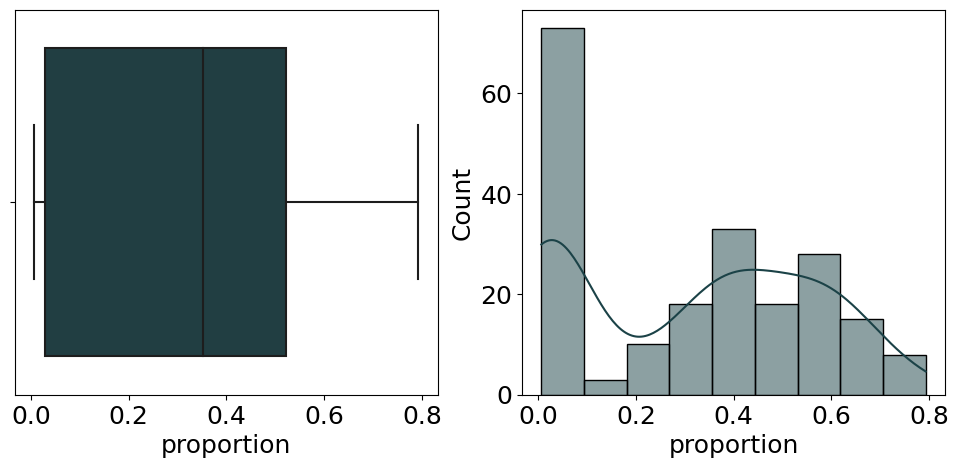

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(ax=axes[0], data=df_filter_stage_2, x="proportion")
sns.histplot(ax=axes[1], data=df_filter_stage_2, x="proportion", kde=True)

#### Desarrollo de un data frame de counting para emplear como índice

In [189]:
counting = df_filter_stage_2[["cell", "subject", "nucl_combination"]].groupby(by=["cell", "subject"]).count()
counting.sort_values(by="nucl_combination", ascending=False)

,,nucl_combination
cell,subject,
TTGCCGTGTCTCTCTG,K6B_S13530-LC,6
GCATACAGTTAGTGGG,K6B_S13530-LC,6
CTGAAGTAGCTGATAA,K7B_S10000-LC,5
GCTCCTAGTCAAACTC,K7B_S10000-LC,4
CCACCTAAGGCAGTCA,K6B_S13530-LC,4
...,...,...
CTCCTAGGTAAACACA,K6B_S13530-LC,3
CTCGAGGCATCCGGGT,K6B_S13530-HC,3
CTTAGGAGTGGCAAAC,K7B_S10000-LC,3


### Estimación de las probailidades de eventos de éxito para la combinación cell/subject

In [190]:
matrix_pbb = []

for index in counting.index:
    cell = index[0]
    subject = index[1]

    pbb_value = get_prob_by_cell(
        df_data=df_filter_stage_2,
        cell=cell,
        subject=subject)
    
    row = [cell, subject, pbb_value]
    matrix_pbb.append(row)

df_pbb = pd.DataFrame(matrix_pbb, columns=['cell', 'subject', 'pbb_success'])
df_pbb

,cell,subject,pbb_success
0,AACACGTCAGCTGGCT,K7B_S10000-LC,0.444444
1,ACCGTAAGTACCCAAT,K6B_S13530-LC,0.375000
2,ACTGAGTCAATCTACG,K6B_S13530-HC,0.444444
3,ACTGTCCAGGGTCTCC,K8B_S13553-LC,0.444444
4,AGGGATGCAATGTAAG,K8B_S13553-LC,0.444444
...,...,...,...
59,TGTGGTATCAGCTTAG,K6B_S13530-HC,0.444444
60,TTAACTCTCGGTCCGA,K8B_S13553-LC,0.444444
61,TTCTCAACACAGGTTT,K7B_S10000-LC,0.444444
62,TTGCCGTGTCTCTCTG,K6B_S13530-LC,0.312500


#### Ploteo de la distribución de las probabilidades

<AxesSubplot: xlabel='pbb_success', ylabel='Count'>

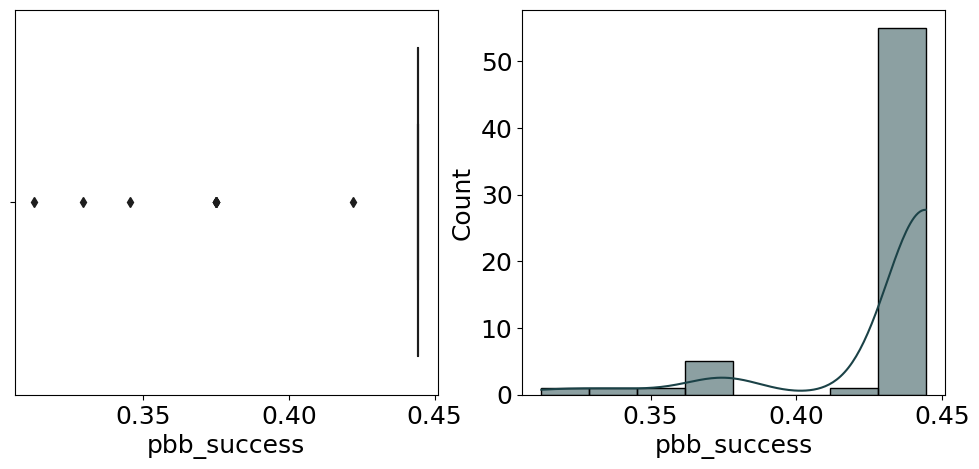

In [191]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(ax=axes[0], data=df_pbb, x="pbb_success")
sns.histplot(ax=axes[1], data=df_pbb, x="pbb_success", kde=True)

#### Binarización de la distribución de probabilidades en función del umbral de interés.

En este caso, se identifica nuevamente una distribución bimodal. El umbral seleccionado es 0.4, ya que es el punto que separa los peaks de la distribución bimodal. 

In [192]:
df_merge_pbb = df_filter_stage_2.merge(right=df_pbb, on=["cell", "subject"])
df_merge_pbb["is_error"] = (df_merge_pbb["pbb_success"] >= 0.4).astype(int)
df_merge_pbb

,subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type,alternative_type,...,highest_count,label,total_umi,umi_percentage,subject_type,umi_count_per_combination,proportion,binarized_proportion,pbb_success,is_error
0,K6B_S13530-HC,AGTTGGTTCTGATACG,"291:C, 255:T, 261:G, 367:T, 400:G","291:G, 255:C, 261:G, 367:C, 400:C",5,105,3,PO-Neo,unexpected,highest_umi_count,...,1,Highest,159,66.037736,HC,159,0.660377,1,0.444444,1
1,K6B_S13530-HC,AGTTGGTTCTGATACG,"291:G, 255:C, 261:A, 367:C, 400:A","291:G, 255:C, 261:G, 367:C, 400:C",5,53,3,PO-Neo,unexpected,all positions alternative,...,1,Opposite,159,33.333333,HC,159,0.333333,1,0.444444,1
2,K6B_S13530-HC,AGTTGGTTCTGATACG,"291:C, 255:T, 261:G, 367:C, 400:G","291:G, 255:C, 261:G, 367:C, 400:C",5,1,3,PO-Neo,unexpected,partial alternative 1,...,1,partial alternative 1,159,0.628931,HC,159,0.006289,0,0.444444,1
3,K6B_S13530-LC,CGGAGCTAGATCACGG,"122:A, 196:C, 278:T, 306:T, 207:A, 187:T, 192:C","122:G, 196:C, 278:T, 306:C, 207:A, 187:T, 192:C",7,104,4,PO-Neo,unexpected,highest_umi_count,...,1,Highest,136,76.470588,LC,136,0.764706,1,0.375000,0
4,K6B_S13530-LC,CGGAGCTAGATCACGG,"122:G, 196:T, 278:A, 306:C, 207:G, 187:C, 192:T","122:G, 196:C, 278:T, 306:C, 207:A, 187:T, 192:C",7,30,4,PO-Neo,unexpected,all positions alternative,...,1,Opposite,136,22.058824,LC,136,0.220588,1,0.375000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,K7B_S10000-LC,GTTCATTAGAAACGCC,"193:A, 375:C, 378:T","193:A, 375:C, 378:C",3,1,4,PO-Neo,unexpected,partial alternative 1,...,1,partial alternative 1,25,4.000000,LC,25,0.040000,0,0.375000,0
202,K7B_S10000-LC,GTTCATTAGAAACGCC,"193:A, 375:C, 378:C","193:A, 375:C, 378:C",3,1,4,PO,unexpected,partial alternative 2,...,1,partial alternative 2,25,4.000000,LC,25,0.040000,0,0.375000,0
203,K8B_S13553-LC,CATCAGAAGGGTGTGT,"213:G, 200:G, 335:C, 203:A, 229:G","213:G, 200:A, 335:G, 203:A, 229:G",5,11,3,PO-Neo,unexpected,highest_umi_count,...,1,Highest,22,50.000000,LC,22,0.500000,1,0.444444,1
204,K8B_S13553-LC,CATCAGAAGGGTGTGT,"213:C, 200:A, 335:G, 203:T, 229:T","213:G, 200:A, 335:G, 203:A, 229:G",5,10,3,PO-Neo,unexpected,all positions alternative,...,1,Opposite,22,45.454545,LC,22,0.454545,1,0.444444,1


### Queries de validación de los métodos propuestos

#### Query 1:

- Célula: TTGCCGTGTCTCTCTG
- Subject: K6B_S13530-LC
- Clasificación esperada: "Error"
- Clasificación obtenida: "Error"
- Justificación: La célula presenta una alta cantidad de nucl_combination_po. A su vez, 3 de sus transcritos se encuentran en valores altos de proporción, mientras que 3 de sus transcritos se encuentran en valores bajos de proporción. Presenta una pbb de éxito del 0.31, por lo cual es rechazada y se clasifica como célula con error.

In [193]:
df_merge_pbb.loc[(df_merge_pbb['cell'] == "TTGCCGTGTCTCTCTG") & (df_merge_pbb['subject'] == "K6B_S13530-LC")]

,subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type,alternative_type,...,highest_count,label,total_umi,umi_percentage,subject_type,umi_count_per_combination,proportion,binarized_proportion,pbb_success,is_error
184,K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:G, 187:C, 207:A","122:G, 187:T, 207:A",3,17,6,PO-Neo,unexpected,highest_umi_count,...,1,Highest,55,30.909091,LC,55,0.309091,1,0.3125,0
185,K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:G, 187:C, 207:G","122:G, 187:T, 207:A",3,16,6,PO-Neo,unexpected,partial alternative 1,...,1,partial alternative 1,55,29.090909,LC,55,0.290909,1,0.3125,0
186,K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:A, 187:T, 207:A","122:G, 187:T, 207:A",3,10,6,PO-Neo,unexpected,partial alternative 2,...,1,partial alternative 2,55,18.181818,LC,55,0.181818,1,0.3125,0
187,K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:G, 187:T, 207:G","122:G, 187:T, 207:A",3,6,6,PO-Neo,unexpected,partial alternative 3,...,1,partial alternative 3,55,10.909091,LC,55,0.109091,0,0.3125,0
188,K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:G, 187:T, 207:A","122:G, 187:T, 207:A",3,3,6,PO,unexpected,partial alternative 4,...,1,partial alternative 4,55,5.454545,LC,55,0.054545,0,0.3125,0
189,K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:A, 187:C, 207:G","122:G, 187:T, 207:A",3,3,6,Neo,unexpected,partial alternative 5,...,1,partial alternative 5,55,5.454545,LC,55,0.054545,0,0.3125,0


#### Query 2:

- Célula: CTGTGCTTCTATCCCG
- Subject: K7B_S10000-LC
- Clasificación esperada: "Normal cell"
- Clasificación obtenida: "Normal cell"
- Justificación: La célula presenta dos transcritos y ambos en proporciones altas con respecto a la distribución global.

In [194]:
df_processed_concat.loc[(df_processed_concat['cell'] == "CTGTGCTTCTATCCCG") & (df_processed_concat['subject'] == "K7B_S10000-LC")]

,cell,subject,positive,negative,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,...,match_percentage_po,highest_count,label,total_umi,umi_percentage,subject_type,umi_count_per_combination,proportion,binarized_proportion,criterion_filter
219,CTGTGCTTCTATCCCG,K7B_S10000-LC,2,0,"185:A, 153:A","185:G, 153:G",2,146,2,Neo,...,0.0,1,Highest,237,61.603376,LC,237,0.616034,1,normal cell
220,CTGTGCTTCTATCCCG,K7B_S10000-LC,2,0,"185:G, 153:G","185:G, 153:G",2,91,2,PO,...,100.0,1,Opposite,237,38.396624,LC,237,0.383966,1,normal cell


#### Query 3:

- Célula: ACCAGTACAGGGATTG
- Subject: K6B_S13530-LC
- Clasificación esperada: "Filter by bi-modal"
- Clasificación obtenida: "Filter by bi-modal"
- Justificación: La célula presenta tres transcritos y todos en proporciones altas con respecto a la distribución global. 

In [195]:
df_processed_concat.loc[(df_processed_concat['cell'] == "ACCAGTACAGGGATTG") & (df_processed_concat['subject'] == "K6B_S13530-LC")]

,cell,subject,positive,negative,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,...,match_percentage_po,highest_count,label,total_umi,umi_percentage,subject_type,umi_count_per_combination,proportion,binarized_proportion,criterion_filter
0,ACCAGTACAGGGATTG,K6B_S13530-LC,3,0,"274:C, 207:G, 247:G","274:C, 207:A, 247:A",3,45,3,PO-Neo,...,33.333333,1,Highest,107,42.056075,LC,107,0.420561,1,Filter by bi-modal
1,ACCAGTACAGGGATTG,K6B_S13530-LC,3,0,"274:C, 207:G, 247:A","274:C, 207:A, 247:A",3,33,3,PO-Neo,...,66.666667,1,partial alternative 1,107,30.841121,LC,107,0.308411,1,Filter by bi-modal
2,ACCAGTACAGGGATTG,K6B_S13530-LC,3,0,"274:T, 207:A, 247:A","274:C, 207:A, 247:A",3,29,3,PO-Neo,...,66.666667,1,Opposite,107,27.102804,LC,107,0.271028,1,Filter by bi-modal


### Etapa final: Resumen y export de resultados

In [203]:
# process bi modal validation
df_processed_concat_filter = df_processed_concat[['cell', 'subject', 'nucl_combination', 'criterion_filter']]

# process binomial validation
array_values = []

for index in df_merge_pbb.index:
    if df_merge_pbb['is_error'][index]:
        array_values.append("normal cell")
    else:
        array_values.append("Filter by binomial")

df_merge_pbb['criterion_filter'] = array_values
df_merge_pbb_filter = df_merge_pbb[['cell', 'subject', 'nucl_combination', 'criterion_filter']]

df_summary = pd.concat([df_processed_concat_filter, df_merge_pbb_filter], axis=0)

df_summary.to_csv("summary_processed_data_cell.csv", index=False)
df_summary['criterion_filter'].value_counts()


normal cell           579
Filter by binomial     37
Filter by bi-modal     27
Name: criterion_filter, dtype: int64

In [207]:
df_count_by_combination= df_summary.groupby(by=['cell', 'subject', 'criterion_filter']).count()

matrix_data = []
for index in df_count_by_combination.index:
    cell = index[0]
    subject = index[1]
    criterion_filter = index[2]
    count = df_count_by_combination['nucl_combination'][index]

    row = [cell, subject, criterion_filter, count]
    matrix_data.append(row)

df_summary_counts = pd.DataFrame(matrix_data, columns=['cell', 'subject', 'status_cell', 'count nucl_combination'])
df_summary_counts.sort_values(by="count nucl_combination", ascending=False).to_csv("summary_counts_processed_data.csv", index=False)